<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/04-20%2002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
import torchvision.transforms as transforms
# 데이터셋을 무작위로 샘플링할때 쓰려고(train/test)
from torch.utils.data.sampler import SubsetRandomSampler

In [2]:
# cuda : gpu 쓰기위한 도구(플랫폼)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
# Compose : 여러 변환들 함께 결합시 사용됨
composed=transforms.Compose([
    transforms.ToTensor(),
    # 각 픽셀값에서 0.1빼고 0.3으로 나눈다(평균 0.1, 표준편차 0.3의 분포로 변)
    transforms.Normalize((0.1,),(0.3,))
])

In [5]:
# root=데이터저장경로
# MNIST 이미지 (1,28,28) -> ToTensor(텐서로 변환) (0~1)
train_data=datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
test_data=datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]


In [6]:
in_data=list(range(60000)) # [0,1, ..... 59999]
np.random.shuffle(in_data) # 번호표를 무작위로 섞어놓음
split_data=int(np.floor(0.2*60000)) # 12000개는 train-validation용으로 설정 48000개는 train용

# train_index : 12001번째부터 마지막까지(48000개) - 학습용
# valid_index : 처음부터 12000번째까지(12000개) - 검증용
train_index, valid_index=in_data[split_data:], in_data[:split_data]

In [8]:
# DataLoader에 전달될때, 12000, 48000 인덱스에 해당하는 데이터를 무작위로 추출하려고
train_sample=SubsetRandomSampler(train_index)
valid_sample=SubsetRandomSampler(valid_index)

In [9]:
from torch.utils.data import DataLoader

In [11]:
# SubsetRandomSampler - DataLoader
# DataLoader 가 다음 값 요청하면 샘플러가 인덱스 하나를 무작위로 던져주는 구조(호환됨)
train_loader=DataLoader(train_data, batch_size=128, sampler=train_sample)
vaild_loader=DataLoader(train_data, batch_size=128, sampler=valid_sample)
# 60000개를 무작위로 섞은 후 80% 학습 20% 검즘용으로 나눔

# 평가시에 데이터 순서가 섞이면 모델 성능 비교 불안정해짐 -> 섞지 않음
test_loader=DataLoader(test_data, batch_size=128, shuffle=False) # 10000개

In [ ]:
# conv1 통과(28-5+2*2)/1+1=28
# => [6,28,28]
# maxpool1 통과 : [6,14,14]
# conv2 통과 (14-5)/1+1=10 => [16,10,10]
# maxpool2 통과 : [16,5,5]

In [19]:
# conv2d 신경망 모델 정의
class LeNet(nn.Module):
  def __init__(self):
    super().__init__()
    # 입력 -> 특징추출
    self.conv1=nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
    self.conv2=nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
    self.maxpool=nn.MaxPool2d(2) # 2*2
    self.relu=nn.ReLU()
    # 2번씩 conv, maxpool 시킨 결과
    self.fc1=nn.Linear(16*5*5, 120)
    self.fc2=nn.Linear(120,84)
    self.fc3=nn.Linear(84,10)

  def forward(self, x):
    x=self.relu(self.conv1(x))
    x=self.maxpool(x)
    x=self.relu(self.conv2(x))
    x=self.maxpool(x)
    # 2D -> 1D
    # fully connected에 전달할 준비!!
    x=torch.flatten(x,1)
    # FC Lavaer
    x=self.relu(self.fc1(x))
    x=self.relu(self.fc2(x))
    out=self.fc3(x)
    return out

In [20]:
model=LeNet()
model

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [21]:
# 이미지데이터, 정답 => 이미지데이터만 뽑으려고 [0]
first_batch=next(iter(train_loader))[0]
first_batch.shape

torch.Size([128, 1, 28, 28])

In [22]:
# 첫번째 배치 데이터에 대한 예측
model.forward(next(iter(train_loader))[0])

tensor([[-0.0724,  0.1248,  0.0637,  ...,  0.0098,  0.0805,  0.0176],
        [-0.0706,  0.1231,  0.0723,  ...,  0.0179,  0.0767,  0.0136],
        [-0.0724,  0.1265,  0.0796,  ...,  0.0128,  0.0787,  0.0110],
        ...,
        [-0.0697,  0.1249,  0.0618,  ...,  0.0185,  0.0726,  0.0183],
        [-0.0757,  0.1225,  0.0684,  ...,  0.0129,  0.0881,  0.0104],
        [-0.0714,  0.1263,  0.0657,  ...,  0.0135,  0.0846,  0.0171]],
       grad_fn=<AddmmBackward0>)

In [25]:
# 다중 분류에서 가장 많이 쓰이는 손실함수
crossloss=nn.CrossEntropyLoss()
# 모델을 cpu로 올린 후에 입력데이터도 cpu로 이동시킴
model.to(device)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [26]:
optimizer=torch.optim.SGD(model.parameters(), lr=0.01)

In [29]:
loss1, acc1=[], []
for epoch in range(10):
  model.train()
  t_loss=0 # 손실 초기화
  t_acc=0 # 정확도 초기화

  for i,j in train_loader:
    i,j=i.to(device), j.to(device)



    z=model(i)
    loss=crossloss(z,j) # CrossEntropyLoss 통해 모델 예측값과 실제 정답사이의 오차
    t_loss+=loss.item()
    # 가장 높은 점수를 뽑아내지 않고, 그게 몇번 클래스인지 알아내기 위해서
    _,y_pred=torch.max(z,1) # 가장 높은 점수를 가진 클래스 인덱스 => (_ : 최대값, y_pred :예측 클래스 번호)
    t_acc+=(y_pred==j).sum().item()

    optimizer.zero_grad() # 기울기 초기화
    loss.backward() # 기울기 계산
    optimizer.step() # 가중치 업데이트

  t_loss=t_loss/len(train_sample)
  t_acc=t_acc/len(train_sample)

  loss1.append(t_loss)
  acc1.append(t_acc)

  print(loss1)
  print(acc1)

[0.017958239609996478]
[0.11320833333333333]
[0.017958239609996478, 0.017819095651308695]
[0.11320833333333333, 0.117125]
[0.017958239609996478, 0.017819095651308695, 0.014920700348913669]
[0.11320833333333333, 0.117125, 0.3718958333333333]
[0.017958239609996478, 0.017819095651308695, 0.014920700348913669, 0.005281749830891688]
[0.11320833333333333, 0.117125, 0.3718958333333333, 0.7841666666666667]
[0.017958239609996478, 0.017819095651308695, 0.014920700348913669, 0.005281749830891688, 0.003203252863449355]
[0.11320833333333333, 0.117125, 0.3718958333333333, 0.7841666666666667, 0.8697708333333334]
[0.017958239609996478, 0.017819095651308695, 0.014920700348913669, 0.005281749830891688, 0.003203252863449355, 0.0024073002769922215]
[0.11320833333333333, 0.117125, 0.3718958333333333, 0.7841666666666667, 0.8697708333333334, 0.9033541666666667]
[0.017958239609996478, 0.017819095651308695, 0.014920700348913669, 0.005281749830891688, 0.003203252863449355, 0.0024073002769922215, 0.0019278097422

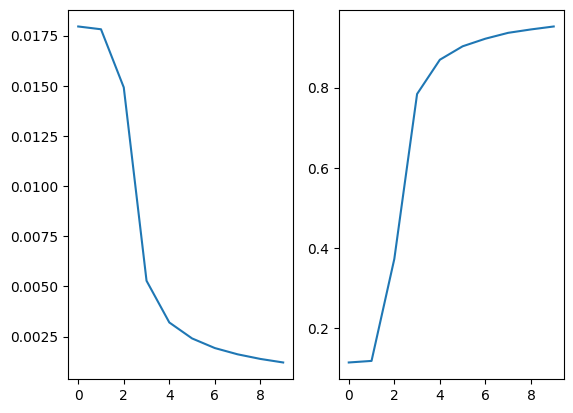

In [30]:
fit, (ax1,ax2)=plt.subplots(1,2)
ax1.plot(loss1)
ax2.plot(acc1)

In [33]:
pred=[]
label=[]

# 모델을 평가모드설정(생략해도됨) -> dropout 이 off 됨
model.eval()
# inference_mode : gradient 비활성 -> 메모리 절약
with torch.inference_mode():
  for i,j in test_loader:
    # 데이터를 현재 디바이스로 이동
    i,j=i.to(device), j.to(device)
    z=model(i)
    val, y_pred=torch.max(z,1)
    # 리스트에 배치단위(128) 결과들을 각각 이어붙인다.
    # numpy는 gpu에 있는 데이터 직접 다룰 수 없음 -> cpu로 바꿔서 가져와야
    pred.extend(y_pred.cpu().numpy())
    label.extend(j.cpu().numpy())

# 모델이 정답을 맞춘 이미지 위치
# pre=[2,8,1,0,4]
# label=[2,6,1,0,4]
# np.nonzero([True, False, True, True, True]) => True인 값 인덱스 반환 -> 0,2,3,4
answer=np.nonzero(np.array(pred)==np.array(label))[0]
incorrect=np.nonzero(np.array(pred)!=np.array(label))[0]

#전체 샘플 중 맞춘 비율
print(len(answer)/len(pred)*100)
print(y_pred)
print(label)

96.2
tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6], device='cuda:0')
[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7

[[ 968    0    2    0    0    1    5    2    2    0]
 [   0 1119    4    1    1    0    3    0    7    0]
 [   8    1  996    5    2    0    5    4   11    0]
 [   2    2    9  966    0   10    0    8   12    1]
 [   2    2    3    0  941    0   11    2    3   18]
 [   8    3    0    6    2  857    7    1    8    0]
 [   9    3    2    0    2    6  935    0    1    0]
 [   1    9   23    3    1    0    0  974    5   12]
 [   6    3    4    4    3    7    6    4  935    2]
 [   9    9    2    8   21    3    0   15   13  929]]
98.77551020408163
98.59030837004406
96.51162790697676
95.64356435643563
95.82484725050917
96.0762331838565
97.59916492693111
94.74708171206225
95.99589322381931
92.07135777998018


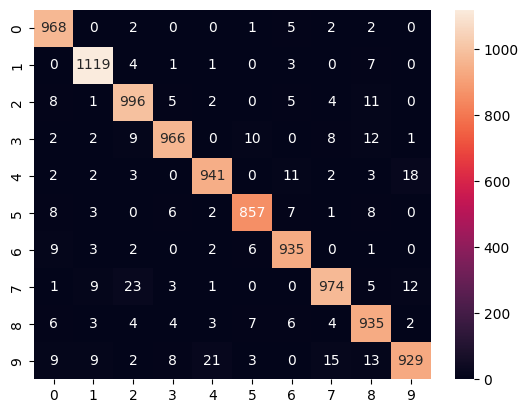

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

con_mtx=confusion_matrix(label, pred)
print(con_mtx)
# 각 셀에 숫자표시(annot), 정수형으로 표시(fmt='d')
sns=sns.heatmap(con_mtx, annot=True, fmt='d')
for i in range(10):
  # con_mtx[i][i] : 실제 i인 샘플 중 올바르게 예측된 수
  # con_mtx[i].sum() : 실제 i클래스의 전체 샘플 수
  # => 각 클래스별로 정확도 계산함
  print(con_mtx[i][i]/con_mtx[i].sum()*100)